#### Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
item_level = pd.read_parquet("data/processed/item_level.parquet")

df = item_level[
    (item_level["order_status"] == "delivered") & (~item_level["is_invalid_timestamps"])
].copy()

#### Category ranking

In [3]:
category_summary = (
    df.groupby("product_category_name_english")
    .agg(
        total_revenue=("price", "sum"),
        n_orders=("order_id", "nunique"),
        avg_price=("price", "mean"),
    )
    .sort_values("total_revenue", ascending=False)
)

print("Top 10 categories by revenue:")
print(category_summary.head(10))

Top 10 categories by revenue:
                               total_revenue  n_orders   avg_price
product_category_name_english                                     
health_beauty                     1211552.01      8495  130.316447
watches_gifts                     1151695.87      5397  200.051393
bed_bath_table                    1008243.08      9131   93.494351
sports_leisure                     944297.98      7447  113.306693
computers_accessories              877346.30      6442  116.251000
furniture_decor                    703283.55      6231   87.288513
cool_stuff                         605603.15      3520  164.610805
housewares                         603595.53      5634   90.861889
auto                               573224.97      3749  140.737778
garden_tools                       465059.58      3402  110.255946


- Top 3 by revenue: health_beauty, watches_gifts, bed_bath_table (1.15M–1.21M BRL each)
- watches_gifts leads on avg price (200 BRL) despite fewer orders than bed_bath_table — value-driven, not volume-driven
- Revenue spread across top 10 is fairly even — no single dominant category

#### Revenue vs Growth matrix

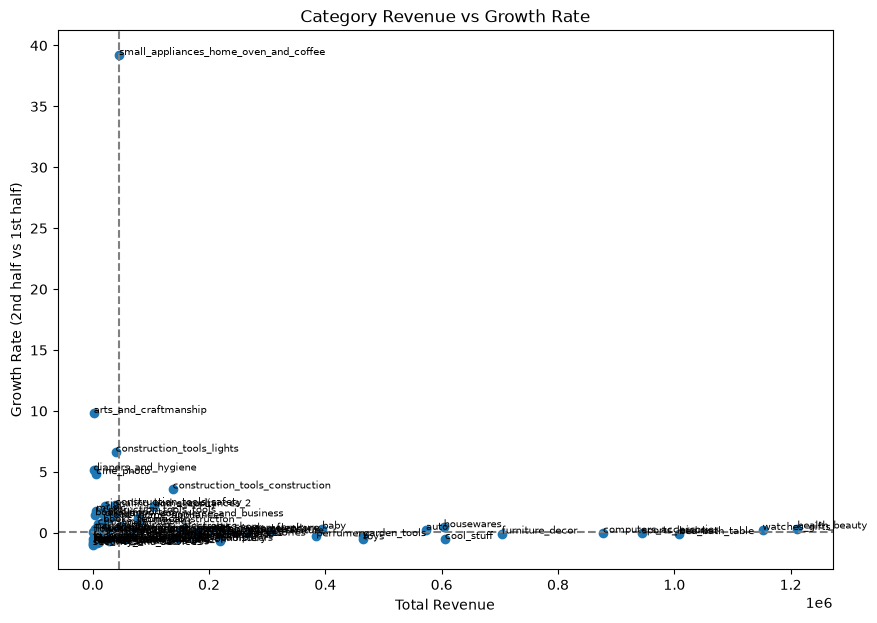

In [5]:
# Split into two halves by purchase date to compute growth rate per category
mid_date = df["order_purchase_timestamp"].median()

first_half = df[df["order_purchase_timestamp"] < mid_date]
second_half = df[df["order_purchase_timestamp"] >= mid_date]

rev_first = first_half.groupby("product_category_name_english")["price"].sum()
rev_second = second_half.groupby("product_category_name_english")["price"].sum()

growth_df = pd.DataFrame({"revenue_first": rev_first, "revenue_second": rev_second}).fillna(0)

# Only compute growth rate for categories with meaningful revenue in the first half
# (avoids inflated/undefined growth rates from near-zero denominators)
growth_df = growth_df[growth_df["revenue_first"] > 100]
growth_df["growth_rate"] = (
    (growth_df["revenue_second"] - growth_df["revenue_first"]) / growth_df["revenue_first"]
)
growth_df["total_revenue"] = growth_df["revenue_first"] + growth_df["revenue_second"]

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(growth_df["total_revenue"], growth_df["growth_rate"])

# Reference lines to split into quadrants (median as threshold)
ax.axvline(growth_df["total_revenue"].median(), color="gray", linestyle="--")
ax.axhline(growth_df["growth_rate"].median(), color="gray", linestyle="--")

for name, row in growth_df.iterrows():
    ax.annotate(name, (row["total_revenue"], row["growth_rate"]), fontsize=7)

ax.set_xlabel("Total Revenue")
ax.set_ylabel("Growth Rate (2nd half vs 1st half)")
ax.set_title("Category Revenue vs Growth Rate")
plt.show()

## Revenue vs Growth Matrix
- High-revenue categories (health_beauty, watches_gifts, bed_bath_table, sports_leisure, computers_accessories, furniture_decor, cool_stuff, housewares, auto) all cluster near **zero growth** → mature, saturated "cash cows"
- High-growth categories (arts_and_craftmanship ~10x, construction_tools_lights ~7x, diapers_and_hygiene ~5x) all have **low revenue** → early-stage, worth watching
- `small_appliances_home_oven_and_coffee` (~40x growth) is likely a small-denominator artifact — verify absolute counts before reporting

#### Sellere performance

In [6]:
seller_summary = (
    df.groupby("seller_id")
    .agg(
        total_revenue=("price", "sum"),
        n_orders=("order_id", "nunique"),
        avg_review=("review_score", "mean"),
    )
    .query("n_orders >= 10")  # exclude sellers with too few orders to avoid noisy averages
    .sort_values("total_revenue", ascending=False)
)

print("Top 10 sellers by revenue:")
print(seller_summary.head(10))

# Sellers with high revenue but low review score — quality risk worth flagging
risk_sellers = seller_summary[
    (seller_summary["total_revenue"] > seller_summary["total_revenue"].quantile(0.75)) &
    (seller_summary["avg_review"] < 3.5)
]
print(f"\nHigh-revenue sellers with low review scores ({len(risk_sellers)} sellers):")
print(risk_sellers)

Top 10 sellers by revenue:
                                  total_revenue  n_orders  avg_review
seller_id                                                            
4869f7a5dfa277a7dca6462dcf3b52b2      225032.83      1112    4.132979
53243585a1d6dc2643021fd1853d8905      217940.44       348    4.128141
4a3ca9315b744ce9f8e9374361493884      195615.92      1756    3.825746
fa1c13f2614d7b5c4749cbc52fecda94      190277.64       574    4.369527
7c67e1448b00f6e969d365cea6b010ab      186400.11       972    3.351412
7e93a43ef30c4f03f38b393420bc753a      163924.51       313    4.366242
da8622b14eb17ae2831f4ac5b9dab84a      157099.97      1285    4.067505
7a67c85e85bb2ce8582c35f2203ad736      138345.82      1132    4.267196
1025f0e2d44d7041d6cf58b6550e0bfa      136402.56       898    3.859928
955fee9216a65b617aa5c0531780ce60      128438.44      1232    4.100982

High-revenue sellers with low review scores (18 sellers):
                                  total_revenue  n_orders  avg_review
sell


- 18 top-25%-revenue sellers have avg review < 3.5
- `7c67e1448b...`: #5 by revenue (186,400 BRL, 972 orders), but only 3.35 review — high volume, weak quality
- `b1b3948701c...`: review 1.93, but only 14 orders — extreme but low sample reliability

### Combined Insight
Olist's revenue is anchored by a few saturated categories, while growth potential and quality risk both sit in smaller, less-visible corners of the marketplace.

**Priority actions:**
1. Audit high-revenue/low-review sellers (start with `7c67e1448b...`) before scaling their volume further
2. Direct marketing toward high-growth, low-revenue categories (arts_and_craftmanship, construction_tools_lights, diapers_and_hygiene)
3. Maintain (don't over-invest in) saturated cash-cow categories

#### Save outputs

In [7]:
# Save category and seller performance tables for later use in dashboard/report
category_summary.to_parquet("data/processed/category_summary.parquet")
growth_df.to_parquet("data/processed/category_growth.parquet")
seller_summary.to_parquet("data/processed/seller_summary.parquet")
risk_sellers.to_parquet("data/processed/risk_sellers.parquet")

print("Saved: category_summary, category_growth, seller_summary, risk_sellers")

Saved: category_summary, category_growth, seller_summary, risk_sellers
